In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import json

%matplotlib inline

rng = np.random.default_rng()

In [2]:
import os
import sys

# Only move up if we are not already at the project root where generate_configs.py is located
if not os.path.exists('generate_configs.py'):
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

from generate_configs import ConfigGenerator

# sigmoid

(0.0, 1.0)

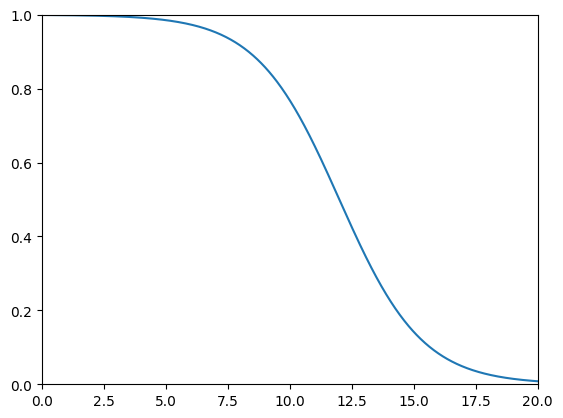

In [3]:
c = -0.6
x0 = 12

x = np.linspace(0, 20, 1000)
y = 1 / (1 + np.exp(-c * (x - x0)))
plt.plot(x, y)
plt.xlim(0, 20)
plt.ylim(0, 1)

(0.0, 100.0)

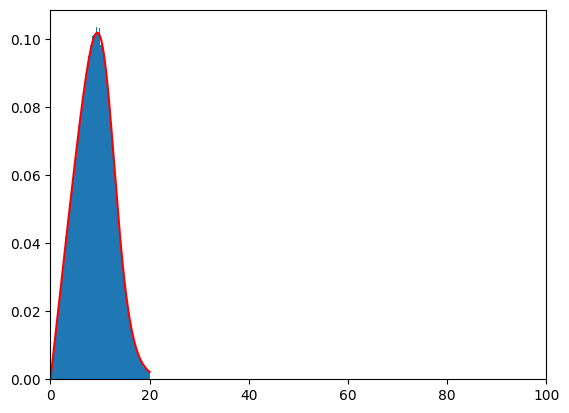

In [4]:
r = x
fr_unnormed = y

norm = np.sum(2 * np.pi * r * fr_unnormed)
fr_latent = 2 * np.pi * r * fr_unnormed / norm

i = np.cumsum(fr_latent)
cdf_inv = interp1d(i, r)

u = rng.uniform(size=(1000000,))
u = u[np.nonzero((np.min(i) < u) & (np.max(i) > u))]
plt.hist(cdf_inv(u), bins=300, density=True)
delta_r = r[1] - r[0]
plt.plot(r, fr_latent / delta_r, 'r-')
plt.xlim(0, 100)

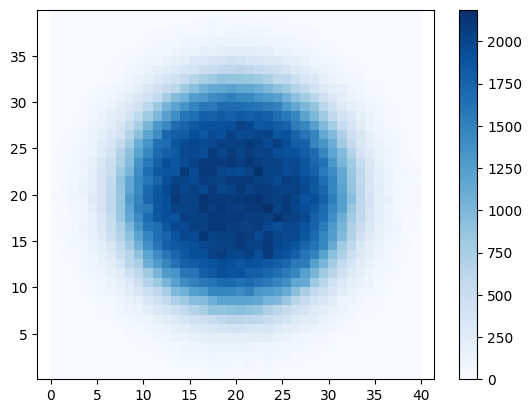

In [5]:
phi = 2 * np.pi * rng.uniform(size=np.size(u))

p = plt.hist2d(cdf_inv(u) * np.cos(phi) + 20, cdf_inv(u) * np.sin(phi) + 20, bins=40, cmap='Blues')
plt.axis('equal')
plt.colorbar()

In [6]:
print(
    json.dumps(
        {
            "request_origin_distributions": [{
                "x": list(x),
                "y": list(y),
                "strength": 1,
                "location": [20, 20]
            }]
        }
    )
)

{"request_origin_distributions": [{"x": [0.0, 0.02002002002002002, 0.04004004004004004, 0.06006006006006006, 0.08008008008008008, 0.10010010010010009, 0.12012012012012012, 0.14014014014014015, 0.16016016016016016, 0.18018018018018017, 0.20020020020020018, 0.22022022022022023, 0.24024024024024024, 0.2602602602602603, 0.2802802802802803, 0.3003003003003003, 0.3203203203203203, 0.34034034034034033, 0.36036036036036034, 0.38038038038038036, 0.40040040040040037, 0.42042042042042044, 0.44044044044044045, 0.46046046046046046, 0.4804804804804805, 0.5005005005005005, 0.5205205205205206, 0.5405405405405406, 0.5605605605605606, 0.5805805805805806, 0.6006006006006006, 0.6206206206206206, 0.6406406406406406, 0.6606606606606606, 0.6806806806806807, 0.7007007007007007, 0.7207207207207207, 0.7407407407407407, 0.7607607607607607, 0.7807807807807807, 0.8008008008008007, 0.8208208208208209, 0.8408408408408409, 0.8608608608608609, 0.8808808808808809, 0.9009009009009009, 0.9209209209209209, 0.9409409409409

# uniform

In [7]:
r = np.linspace(0, 20, 1000)
fr_unnormed = np.ones(shape=np.size(r))
location = [20, 20]

1.0


(0.0, 20.0)

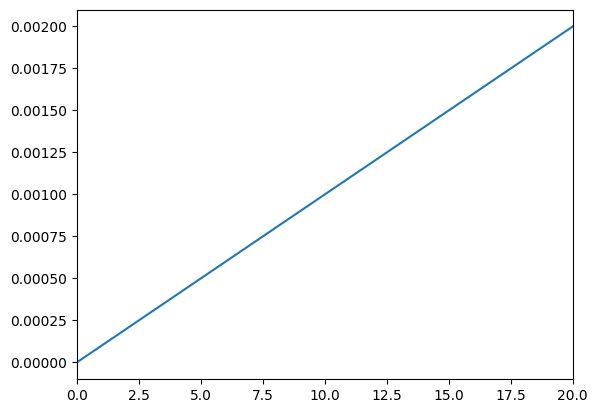

In [8]:
l = 0.1

r = np.linspace(0, 20, 1000)
fr_unnormed = np.ones(shape=np.size(r))

norm = np.sum(2 * np.pi * r * fr_unnormed)
fr_latent = 2 * np.pi * r * fr_unnormed / norm

print(np.sum(fr_latent))

plt.plot(r, fr_latent)
plt.xlim(0, 20)

Cumulative Distribution Function (CDF)

In [9]:
i = np.cumsum(fr_latent)
cdf_inv = interp1d(i, r)

Generating points

(0.0, 100.0)

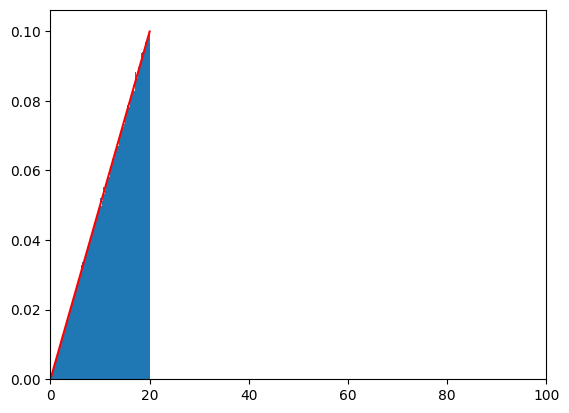

In [10]:
u = rng.uniform(size=(1000000,))
u = u[np.nonzero((np.min(i) < u) & (np.max(i) > u))]
plt.hist(cdf_inv(u), bins=300, density=True)
delta_r = r[1] - r[0]
plt.plot(r, fr_latent / delta_r, 'r-')
plt.xlim(0, 100)

Map to 2D coordinates

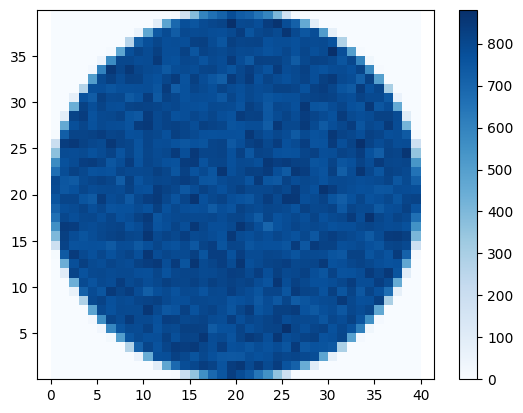

In [11]:
phi = 2 * np.pi * rng.uniform(size=np.size(u))

p = plt.hist2d(cdf_inv(u) * np.cos(phi) + 20, cdf_inv(u) * np.sin(phi) + 20, bins=40, cmap='Blues')
plt.axis('equal')
plt.colorbar()

In [12]:
print(
    json.dumps(
        {
            "request_origin_distributions": [{
                "x": list(r),
                "y": list(fr_unnormed),
                "strength": 1,
                "location": [20, 20]
            }]
        }
    )
)

{"request_origin_distributions": [{"x": [0.0, 0.02002002002002002, 0.04004004004004004, 0.06006006006006006, 0.08008008008008008, 0.10010010010010009, 0.12012012012012012, 0.14014014014014015, 0.16016016016016016, 0.18018018018018017, 0.20020020020020018, 0.22022022022022023, 0.24024024024024024, 0.2602602602602603, 0.2802802802802803, 0.3003003003003003, 0.3203203203203203, 0.34034034034034033, 0.36036036036036034, 0.38038038038038036, 0.40040040040040037, 0.42042042042042044, 0.44044044044044045, 0.46046046046046046, 0.4804804804804805, 0.5005005005005005, 0.5205205205205206, 0.5405405405405406, 0.5605605605605606, 0.5805805805805806, 0.6006006006006006, 0.6206206206206206, 0.6406406406406406, 0.6606606606606606, 0.6806806806806807, 0.7007007007007007, 0.7207207207207207, 0.7407407407407407, 0.7607607607607607, 0.7807807807807807, 0.8008008008008007, 0.8208208208208209, 0.8408408408408409, 0.8608608608608609, 0.8808808808808809, 0.9009009009009009, 0.9209209209209209, 0.9409409409409

# exponential

Probability Density Function (PDF)

In [13]:
l = 0.1
r = np.linspace(0, 40, 1000)
fr_unnormed = np.exp(-l * r)
location = [20, 20]


1.0


(0.0, 20.0)

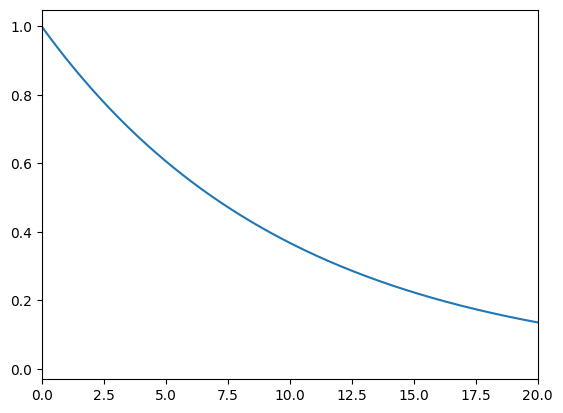

In [14]:
norm = np.sum(2 * np.pi * r * fr_unnormed)
fr_latent = 2 * np.pi * r * fr_unnormed / norm

print(np.sum(fr_latent))

plt.plot(r, fr_unnormed)
plt.xlim(0, 20)

Cumulative Distribution Function (CDF)

In [15]:
i = np.cumsum(fr_latent)
cdf_inv = interp1d(i, r)

Generating points

(0.0, 20.0)

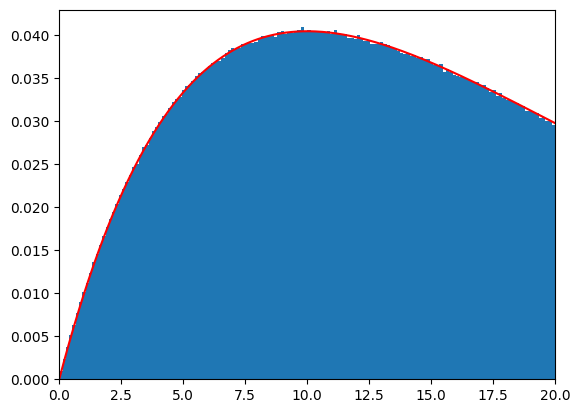

In [16]:
u = rng.uniform(size=(10000000,))
u = u[np.nonzero((np.min(i) < u) & (np.max(i) > u))]
plt.hist(cdf_inv(u), bins=300, density=True)
delta_r = r[1] - r[0]
plt.plot(r, fr_latent / delta_r, 'r-')
plt.xlim(0, 20)

Map to 2D coordinates

In [17]:
phi = 2 * np.pi * rng.uniform(size=np.size(u))

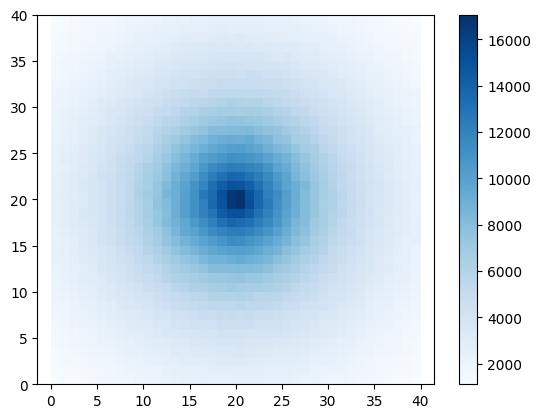

In [18]:
p = plt.hist2d(cdf_inv(u) * np.cos(phi) + 20, cdf_inv(u) * np.sin(phi) + 20, bins=40, range=((0, 40), (0, 40)),
               cmap='Blues')
plt.xlim(0, 40)
plt.ylim(0, 40)
plt.axis('equal')
plt.colorbar()

In [19]:
print(
    json.dumps(
        {
            "request_origin_distributions": [{
                "x": list(r),
                "y": list(fr_unnormed),
                "strength": 1,
                "location": [20, 20]
            }]
        }
    )
)

{"request_origin_distributions": [{"x": [0.0, 0.04004004004004004, 0.08008008008008008, 0.12012012012012012, 0.16016016016016016, 0.20020020020020018, 0.24024024024024024, 0.2802802802802803, 0.3203203203203203, 0.36036036036036034, 0.40040040040040037, 0.44044044044044045, 0.4804804804804805, 0.5205205205205206, 0.5605605605605606, 0.6006006006006006, 0.6406406406406406, 0.6806806806806807, 0.7207207207207207, 0.7607607607607607, 0.8008008008008007, 0.8408408408408409, 0.8808808808808809, 0.9209209209209209, 0.960960960960961, 1.001001001001001, 1.0410410410410411, 1.0810810810810811, 1.1211211211211212, 1.1611611611611612, 1.2012012012012012, 1.2412412412412412, 1.2812812812812813, 1.3213213213213213, 1.3613613613613613, 1.4014014014014013, 1.4414414414414414, 1.4814814814814814, 1.5215215215215214, 1.5615615615615615, 1.6016016016016015, 1.6416416416416417, 1.6816816816816818, 1.7217217217217218, 1.7617617617617618, 1.8018018018018018, 1.8418418418418419, 1.8818818818818819, 1.92192

# Generating sample configs

In [20]:
gen = ConfigGenerator('2019_05_06_base.conf')
conf = gen.generate_config(100, 1, "nearest", 0, 1)
fname, conf_content = gen.dump_config(conf)
print(conf_content)

{
    "n": 40,
    "m": 40,
    "price_fixed": 450,
    "base_coords": [
        20,
        20
    ],
    "price_per_dist": 140,
    "hard_limit": 10,
    "cost_per_unit": 13,
    "log": false,
    "show_map_labels": false,
    "show_pending": false,
    "show_plot": false,
    "max_request_waiting_time": 30,
    "max_time": 14400.0,
    "batch_size": 180,
    "request_origin_distributions": [
        {
            "location": [
                20,
                20
            ],
            "strength": 1,
            "sigma": 10
        }
    ],
    "geom": 0,
    "R": 1,
    "d": 100,
    "num_taxis": 1600,
    "avg_request_lengths": 20.1,
    "request_rate": 79.60199004975124,
    "matching": "nearest",
    "behaviour": "stay",
    "initial_conditions": "base",
    "reset": "false",
    "break_after_work_time": 1440,
    "break_after_waiting_time": 360,
    "break_duration": 90,
    "driver_break_cohort_mix": {
        "short_shift": 0.5,
        "mid_shift": 0.3,
        "long_s